# Test 1: Pure Cubic Perturbation Analysis

**Perturbation**: `Δa = -α₃·θ³` (single term, no lower-order contamination)

| Parameter | Value |
|-----------|-------|
| η₁ | 0 |
| η₂ | 0 |
| η₃ | 0.1125 |
| α₃ = 3·η₃/(m·l²) | 0.3375 |
| True Δa | -0.3375·θ³ |
| True ΔV | M\_scale · (α₃/4)·θ⁴ |

**Goal**: Does the pipeline give a clean single-term recovery when there are no lower-order terms to interfere?

In [51]:
import os, sys
VENV_PATH = "/Users/harshit/Documents/UWM/F25/799-IS/Lagrangian_caVAE-main/.venv/lib/python3.9/site-packages"
if VENV_PATH not in sys.path:
    sys.path.append(VENV_PATH)

_cwd = os.path.abspath('')
PROJECT_ROOT = _cwd
for _ in range(5):
    if os.path.isdir(os.path.join(PROJECT_ROOT, 'examples')):
        break
    PROJECT_ROOT = os.path.dirname(PROJECT_ROOT)
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from sklearn.metrics import r2_score
from pytorch_lightning import seed_everything

seed_everything(0)
%matplotlib inline

from examples.pend_lag_cavae_trainer import Model

# Patch torch.load for PyTorch 2.6+ (idempotent)
if not hasattr(torch, '_orig_load'):
    torch._orig_load = torch.load
    def _patched_load(*args, **kwargs):
        kwargs.setdefault('weights_only', False)
        return torch._orig_load(*args, **kwargs)
    torch.load = _patched_load

print(f"Project root: {PROJECT_ROOT}")

Project root: /Users/harshit/Documents/UWM/F25/799-IS/Lagrangian_caVAE-main


## Configuration

In [52]:
# ============================================================
# CONFIGURATION
# ============================================================
CKPT_UNPERTURBED = 'pend-lag-cavae-T_p=4-epoch=983-step=7871.ckpt'
CKPT_PERTURBED   = 'pend-lag-cavae-T_p=4-epoch=860-step=6887.ckpt'

# Ground truth: PURE CUBIC
ETA1, ETA2, ETA3 = 0.0, 0.0, 0.1125
M_TRUE, L_TRUE = 1.0, 1.0
ALPHA1 = 3 * ETA1 / (M_TRUE * L_TRUE**2)  # 0.0
ALPHA2 = 3 * ETA2 / (M_TRUE * L_TRUE**2)  # 0.0
ALPHA3 = 3 * ETA3 / (M_TRUE * L_TRUE**2)  # 0.3375

N_SAMPLES = 500
THETA_MIN, THETA_MAX = 0, 2 * np.pi
DPI = 150

print(f"True perturbation: Δa = {-ALPHA1:.4f}·θ + {-ALPHA2:.4f}·θ² + {-ALPHA3:.4f}·θ³")
print(f"  α₁ = {ALPHA1:.4f}, α₂ = {ALPHA2:.4f}, α₃ = {ALPHA3:.4f}")
print(f"  This is a PURE CUBIC perturbation (α₁ = α₂ = 0)")

True perturbation: Δa = -0.0000·θ + -0.0000·θ² + -0.3375·θ³
  α₁ = 0.0000, α₂ = 0.0000, α₃ = 0.3375
  This is a PURE CUBIC perturbation (α₁ = α₂ = 0)


## 1. Load Models

In [53]:
ckpt_dir = os.path.join(PROJECT_ROOT, 'results', 'pend')

model_unpert = Model.load_from_checkpoint(
    os.path.join(ckpt_dir, CKPT_UNPERTURBED), map_location='cpu')
model_unpert.eval()

model_pert = Model.load_from_checkpoint(
    os.path.join(ckpt_dir, CKPT_PERTURBED), map_location='cpu')
model_pert.eval()

print("Both models loaded.")

Both models loaded.


## 2. Helper Functions

In [54]:
def extract_physics(model, theta_np):
    theta = torch.tensor(theta_np, dtype=torch.float32, requires_grad=True)
    cos_q = torch.cos(theta)
    sin_q = torch.sin(theta)
    cos_sin = torch.stack((cos_q, sin_q), dim=1)
    V = model.ode.V_net(cos_sin)
    M = model.ode.M_net(cos_sin)
    dV = torch.autograd.grad(V.sum(), theta, create_graph=False)[0]
    M_flat = M.squeeze()
    acc = -(1.0 / M_flat) * dV
    return {
        'V': V.detach().numpy().flatten(),
        'M': M_flat.detach().numpy().flatten(),
        'acc': acc.detach().numpy().flatten(),
    }

def calibrate_phase_offset(phi, a_unpert, g=10.0, l=1.0):
    K = 3 * g / (2 * l)
    best = None
    for s in [1.0, -1.0]:
        for off0 in np.linspace(0, 2*np.pi, 40):
            res = minimize(
                lambda o: np.mean((a_unpert - (-K * np.sin(s * (phi + o[0]))))**2),
                [off0], method='Nelder-Mead')
            if best is None or res.fun < best[0]:
                best = (res.fun, s, res.x[0])
    mse, sign, offset = best
    return {'offset': offset, 'sign': sign, 'mse': mse}

def phi_to_theta_phys(phi, calib):
    theta = calib['sign'] * (phi + calib['offset'])
    return ((theta + np.pi) % (2 * np.pi)) - np.pi

print("Helpers defined.")

Helpers defined.


## 3. Extract Physics & Calibrate

In [55]:
theta_range = np.linspace(THETA_MIN, THETA_MAX, N_SAMPLES)

phys_unpert = extract_physics(model_unpert, theta_range)
phys_pert = extract_physics(model_pert, theta_range)

# Calibrate phase offset
calib = calibrate_phase_offset(theta_range, phys_unpert['acc'])
print(f"Phase calibration: sign={calib['sign']:+.0f}, offset={calib['offset']:.4f} rad, MSE={calib['mse']:.4f}")

theta_phys = phi_to_theta_phys(theta_range, calib)
sort_idx = np.argsort(theta_phys)
theta_phys_sorted = theta_phys[sort_idx]

# Compute perturbation signals
delta_a_sorted = (phys_pert['acc'] - phys_unpert['acc'])[sort_idx]

V_unpert_aligned = phys_unpert['V'] - phys_unpert['V'][0]
V_pert_aligned = phys_pert['V'] - phys_pert['V'][0]
delta_V_sorted = (V_pert_aligned - V_unpert_aligned)[sort_idx]
delta_V_sorted = delta_V_sorted - delta_V_sorted[0]  # zero-anchor

M_scale = np.mean(phys_pert['M'])

# Ground truth
true_da = -ALPHA1 * theta_phys_sorted - ALPHA2 * theta_phys_sorted**2 - ALPHA3 * theta_phys_sorted**3
true_dV_raw = M_scale * ((ALPHA1/2)*theta_phys_sorted**2 + (ALPHA2/3)*theta_phys_sorted**3 + (ALPHA3/4)*theta_phys_sorted**4)

true_dV = true_dV_raw - true_dV_raw[0]  # zero-anchored

print(f"M_scale = {M_scale:.4f}")
print(f"\nΔa range: [{delta_a_sorted.min():.3f}, {delta_a_sorted.max():.3f}]")
print(f"ΔV range: [{delta_V_sorted.min():.3f}, {delta_V_sorted.max():.3f}]")
print(f"\nR²(Δa vs GT) = {r2_score(true_da, delta_a_sorted):.4f}")
print(f"R²(ΔV vs GT, zero-anchored)     = {r2_score(true_dV, delta_V_sorted):.4f}")


Phase calibration: sign=+1, offset=2.2050 rad, MSE=0.6618
M_scale = 0.6915

Δa range: [-10.155, 13.441]
ΔV range: [-6.090, 0.170]

R²(Δa vs GT) = 0.7948
R²(ΔV vs GT, zero-anchored)     = 0.8227


## 4. Overview Plots

Compare learned V, M, and acceleration for both models, plus Δa and ΔV perturbation signals.

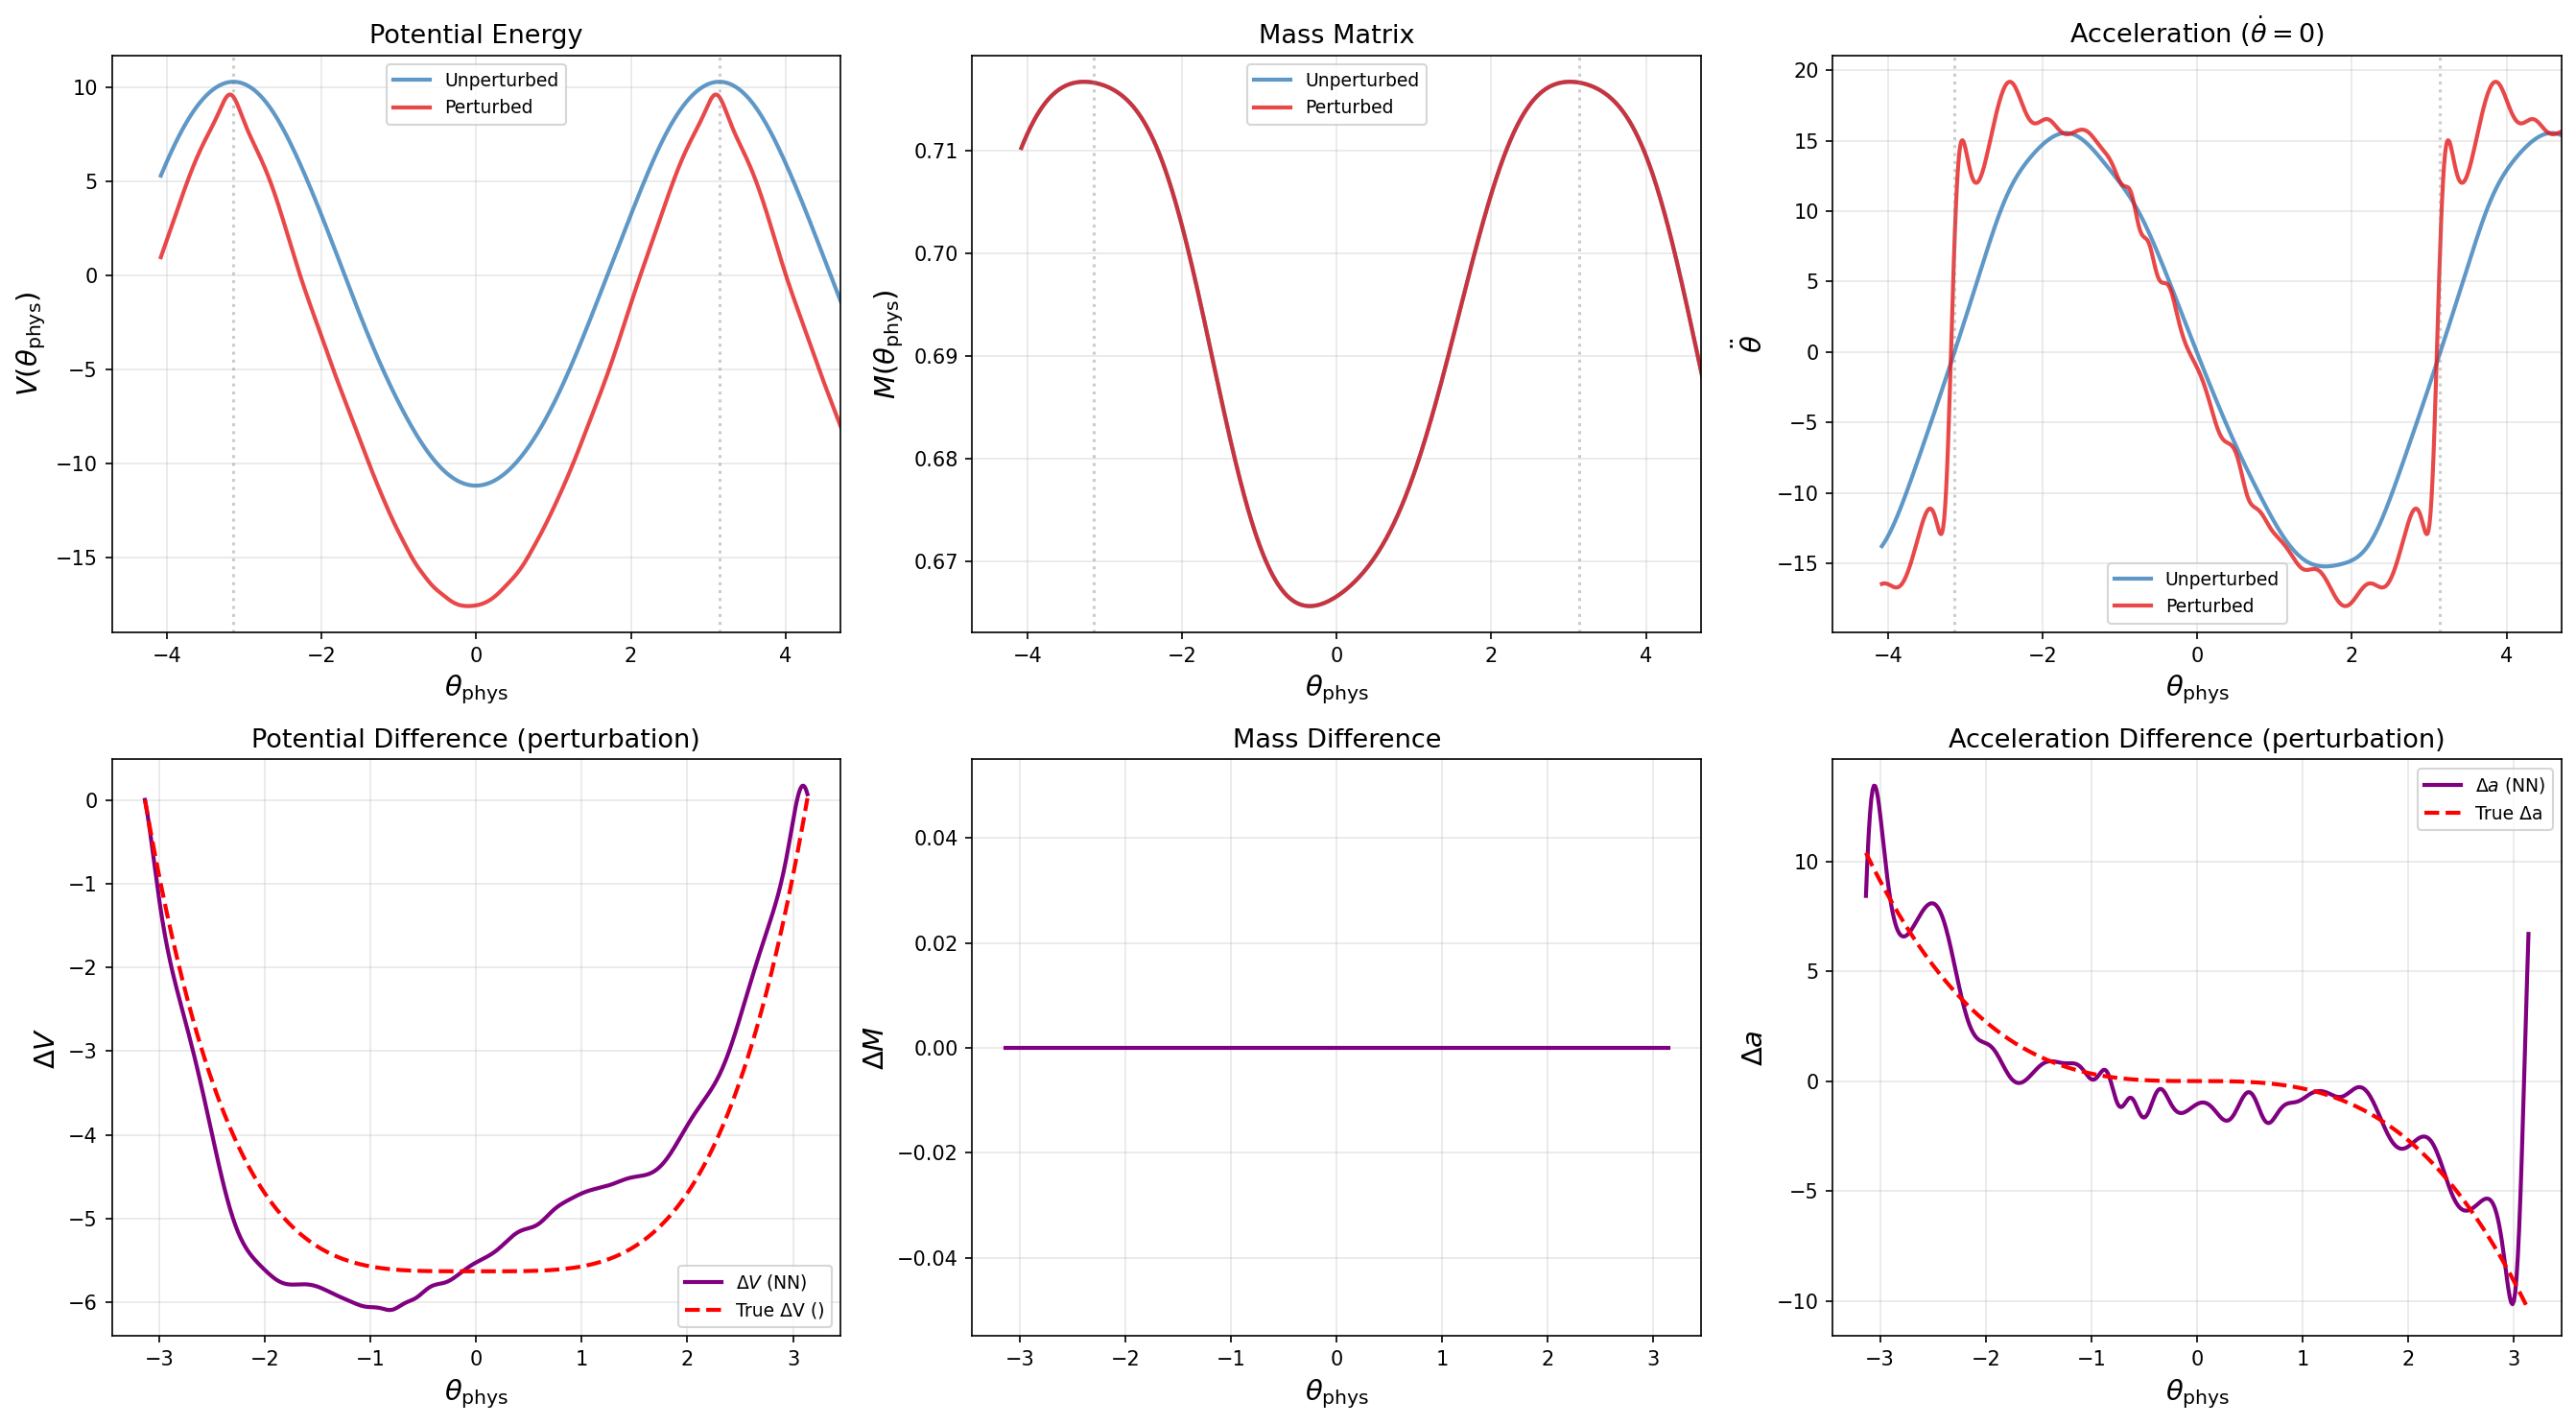

Row 1: Extended range [-2π, 2π] so peak is visible on both sides.
Gray dotted lines mark θ = ±π (the wrapped boundary).
Row 2: Differences on [-π, π] where regression is performed.


In [56]:
# Extended range [-2pi, 2pi] so the peak is fully visible
# V_net takes (cos, sin) so it's periodic — we just evaluate on a wider phi range
phi_ext = np.linspace(-2*np.pi, 2*np.pi, 1000)  # 2 full periods
phys_unpert_ext = extract_physics(model_unpert, phi_ext)
phys_pert_ext = extract_physics(model_pert, phi_ext)

# Convert to theta_phys using same calibration
theta_phys_ext = phi_to_theta_phys(phi_ext, calib)
# DON'T wrap to [-pi, pi] — let it extend naturally
theta_phys_ext_unwrapped = calib['sign'] * (phi_ext + calib['offset'])
# Shift so it's centered: subtract the value at phi=0
theta_center = calib['sign'] * calib['offset']
theta_phys_ext_unwrapped = theta_phys_ext_unwrapped - np.round(theta_center / (2*np.pi)) * 2*np.pi
sort_ext = np.argsort(theta_phys_ext_unwrapped)
theta_ext_sorted = theta_phys_ext_unwrapped[sort_ext]

fig, axes = plt.subplots(2, 3, figsize=(18, 10), dpi=DPI)

labels = ['Unperturbed', 'Perturbed']
colors = ['#377eb8', '#e41a1c']
data_ext = [phys_unpert_ext, phys_pert_ext]

# Row 1: Raw V, M, acc on extended range
for i, (key, ylabel, title) in enumerate([
    ('V',   r'$V(\theta_{\mathrm{phys}})$',          'Potential Energy'),
    ('M',   r'$M(\theta_{\mathrm{phys}})$',          'Mass Matrix'),
    ('acc', r'$\ddot{\theta}$',  r'Acceleration ($\dot{\theta}=0$)'),
]):
    for d, label, c in zip(data_ext, labels, colors):
        axes[0, i].plot(theta_ext_sorted, d[key][sort_ext], color=c, lw=2, label=label, alpha=0.8)
    axes[0, i].set_xlabel(r'$\theta_{\mathrm{phys}}$', fontsize=14)
    axes[0, i].set_ylabel(ylabel, fontsize=14)
    axes[0, i].set_title(title, fontsize=13)
    axes[0, i].legend(fontsize=9)
    axes[0, i].grid(True, alpha=0.3)
    axes[0, i].axvline(x=-np.pi, color='gray', ls=':', alpha=0.4)
    axes[0, i].axvline(x=np.pi, color='gray', ls=':', alpha=0.4)
# Crop x-axis to 1.5 periods
for i in range(3):
    axes[0, i].set_xlim(-1.5*np.pi, 1.5*np.pi)
# Row 2: Differences on the original [-pi, pi] range (regression data)
# V_diff uses delta_V_sorted (zero-anchored subtraction, computed in cell above)
M_diff = (phys_pert['M'] - phys_unpert['M'])[sort_idx]

ax = axes[1, 0]
ax.plot(theta_phys_sorted, delta_V_sorted, 'purple', lw=2, label=r'$\Delta V$ (NN)')
ax.plot(theta_phys_sorted, true_dV, 'r--', lw=2, label='True \u0394V ()')
ax.set_xlabel(r'$\theta_{\mathrm{phys}}$', fontsize=14)
ax.set_ylabel(r'$\Delta V$', fontsize=14)
ax.set_title('Potential Difference (perturbation)', fontsize=13)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[1, 1]
ax.plot(theta_phys_sorted, M_diff, 'purple', lw=2)
ax.set_xlabel(r'$\theta_{\mathrm{phys}}$', fontsize=14)
ax.set_ylabel(r'$\Delta M$', fontsize=14)
ax.set_title('Mass Difference', fontsize=13)
ax.grid(True, alpha=0.3)

ax = axes[1, 2]
ax.plot(theta_phys_sorted, delta_a_sorted, 'purple', lw=2, label=r'$\Delta a$ (NN)')
ax.plot(theta_phys_sorted, true_da, 'r--', lw=2, label='True \u0394a')
ax.set_xlabel(r'$\theta_{\mathrm{phys}}$', fontsize=14)
ax.set_ylabel(r'$\Delta a$', fontsize=14)
ax.set_title('Acceleration Difference (perturbation)', fontsize=13)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Row 1: Extended range [-2\u03c0, 2\u03c0] so peak is visible on both sides.")
print("Gray dotted lines mark \u03b8 = \u00b1\u03c0 (the wrapped boundary).")
print("Row 2: Differences on [-\u03c0, \u03c0] where regression is performed.")

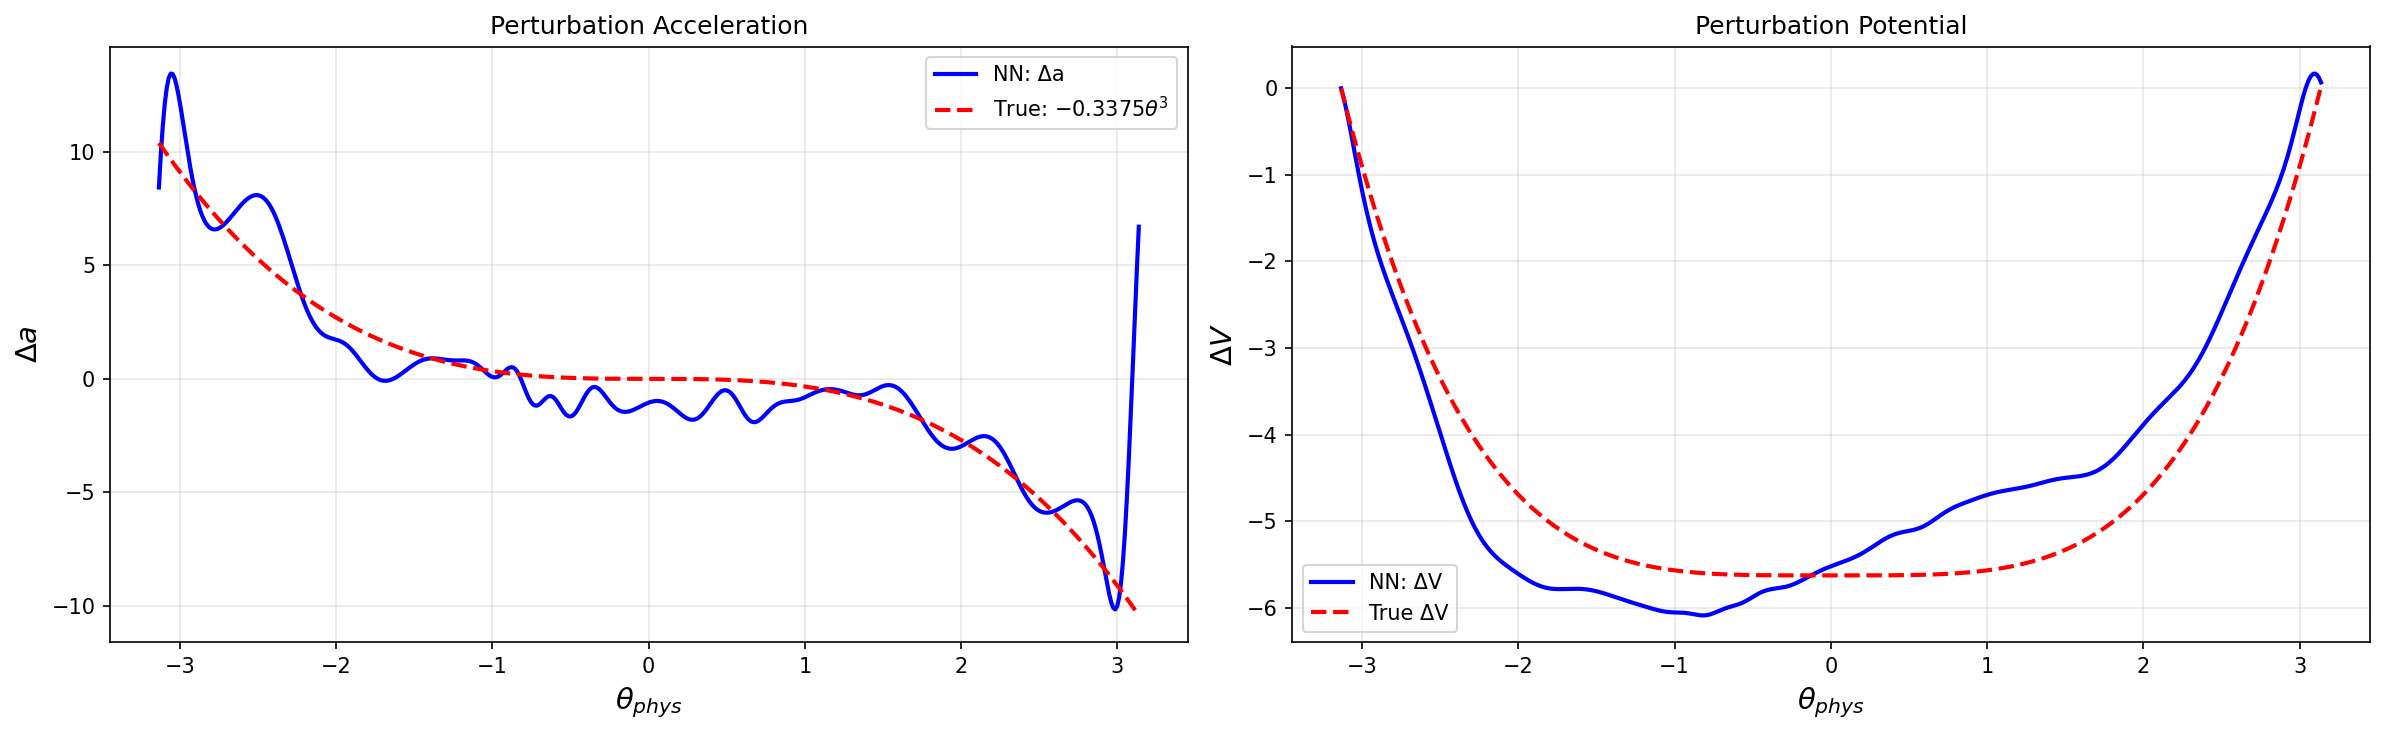

In [57]:
# Perturbation signals: Δa and ΔV
fig, axes = plt.subplots(1, 2, figsize=(16, 5), dpi=DPI)

ax = axes[0]
ax.plot(theta_phys_sorted, delta_a_sorted, 'b-', lw=2, label='NN: Δa')
ax.plot(theta_phys_sorted, true_da, 'r--', lw=2, label=r'True: $-0.3375\theta^3$')
ax.set_xlabel(r'$\theta_{phys}$', fontsize=14)
ax.set_ylabel(r'$\Delta a$', fontsize=14)
ax.set_title('Perturbation Acceleration')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(theta_phys_sorted, delta_V_sorted, 'b-', lw=2, label='NN: ΔV')
ax.plot(theta_phys_sorted, true_dV, 'r--', lw=2, label='True ΔV')
ax.set_xlabel(r'$\theta_{phys}$', fontsize=14)
ax.set_ylabel(r'$\Delta V$', fontsize=14)
ax.set_title('Perturbation Potential')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Polynomial Regression

In [58]:
print("=" * 65)
print("POLYNOMIAL REGRESSION")
print("=" * 65)

print("\n--- Δa ---")
print(f"True: Δa = {-ALPHA3:.4f}·θ³  (pure cubic)")

for deg in [3, 4, 5]:
    coeffs = np.polyfit(theta_phys_sorted, delta_a_sorted, deg)
    pred = np.polyval(coeffs, theta_phys_sorted)
    r2 = 1 - np.sum((delta_a_sorted - pred)**2) / np.sum((delta_a_sorted - delta_a_sorted.mean())**2)
    print(f"\n  Degree {deg} (R² = {r2:.6f}):")
    for i, c in enumerate(coeffs):
        power = deg - i
        if abs(c) > 1e-6:
            true_val = -ALPHA3 if power == 3 else (-ALPHA2 if power == 2 else (-ALPHA1 if power == 1 else 0))
            ratio_str = f"  (true: {true_val:.4f}, ratio: {c/true_val:.3f})" if abs(true_val) > 1e-8 else "  (true: 0, SPURIOUS)" if abs(c) > 0.01 else ""
            print(f"    θ^{power}: {c:+.6f}{ratio_str}")

print("\n\n--- ΔV ---")
true_dv_theta4 = M_scale * ALPHA3 / 4
print(f"True: ΔV = {true_dv_theta4:.4f}·θ⁴  (pure quartic, M_scale={M_scale:.4f})")

for deg in [4, 5, 6]:
    coeffs = np.polyfit(theta_phys_sorted, delta_V_sorted, deg)
    pred = np.polyval(coeffs, theta_phys_sorted)
    r2 = 1 - np.sum((delta_V_sorted - pred)**2) / np.sum((delta_V_sorted - delta_V_sorted.mean())**2)
    print(f"\n  Degree {deg} (R² = {r2:.6f}):")
    for i, c in enumerate(coeffs):
        power = deg - i
        if abs(c) > 1e-6:
            true_val = true_dv_theta4 if power == 4 else 0
            ratio_str = f"  (true: {true_val:.6f}, ratio: {c/true_val:.3f})" if abs(true_val) > 1e-8 else "  (true: 0, SPURIOUS)" if abs(c) > 0.01 else ""
            print(f"    θ^{power}: {c:+.6f}{ratio_str}")

POLYNOMIAL REGRESSION

--- Δa ---
True: Δa = -0.3375·θ³  (pure cubic)

  Degree 3 (R² = 0.871111):
    θ^3: -0.305140  (true: -0.3375, ratio: 0.904)
    θ^2: +0.333984  (true: 0, SPURIOUS)
    θ^1: -0.084043  (true: 0, SPURIOUS)
    θ^0: -1.113593  (true: 0, SPURIOUS)

  Degree 4 (R² = 0.876213):
    θ^4: +0.039577  (true: 0, SPURIOUS)
    θ^3: -0.305447  (true: -0.3375, ratio: 0.905)
    θ^2: -0.000688
    θ^1: -0.082127  (true: 0, SPURIOUS)
    θ^0: -0.782874  (true: 0, SPURIOUS)

  Degree 5 (R² = 0.884062):
    θ^5: +0.031096  (true: 0, SPURIOUS)
    θ^4: +0.039204  (true: 0, SPURIOUS)
    θ^3: -0.646540  (true: -0.3375, ratio: 1.916)
    θ^2: +0.002202
    θ^1: +0.640177  (true: 0, SPURIOUS)
    θ^0: -0.784792  (true: 0, SPURIOUS)


--- ΔV ---
True: ΔV = 0.0583·θ⁴  (pure quartic, M_scale=0.6915)

  Degree 4 (R² = 0.994998):
    θ^4: +0.066358  (true: 0.058347, ratio: 1.137)
    θ^3: -0.058874  (true: 0, SPURIOUS)
    θ^2: -0.074139  (true: 0, SPURIOUS)
    θ^1: +0.652340  (true: 0,

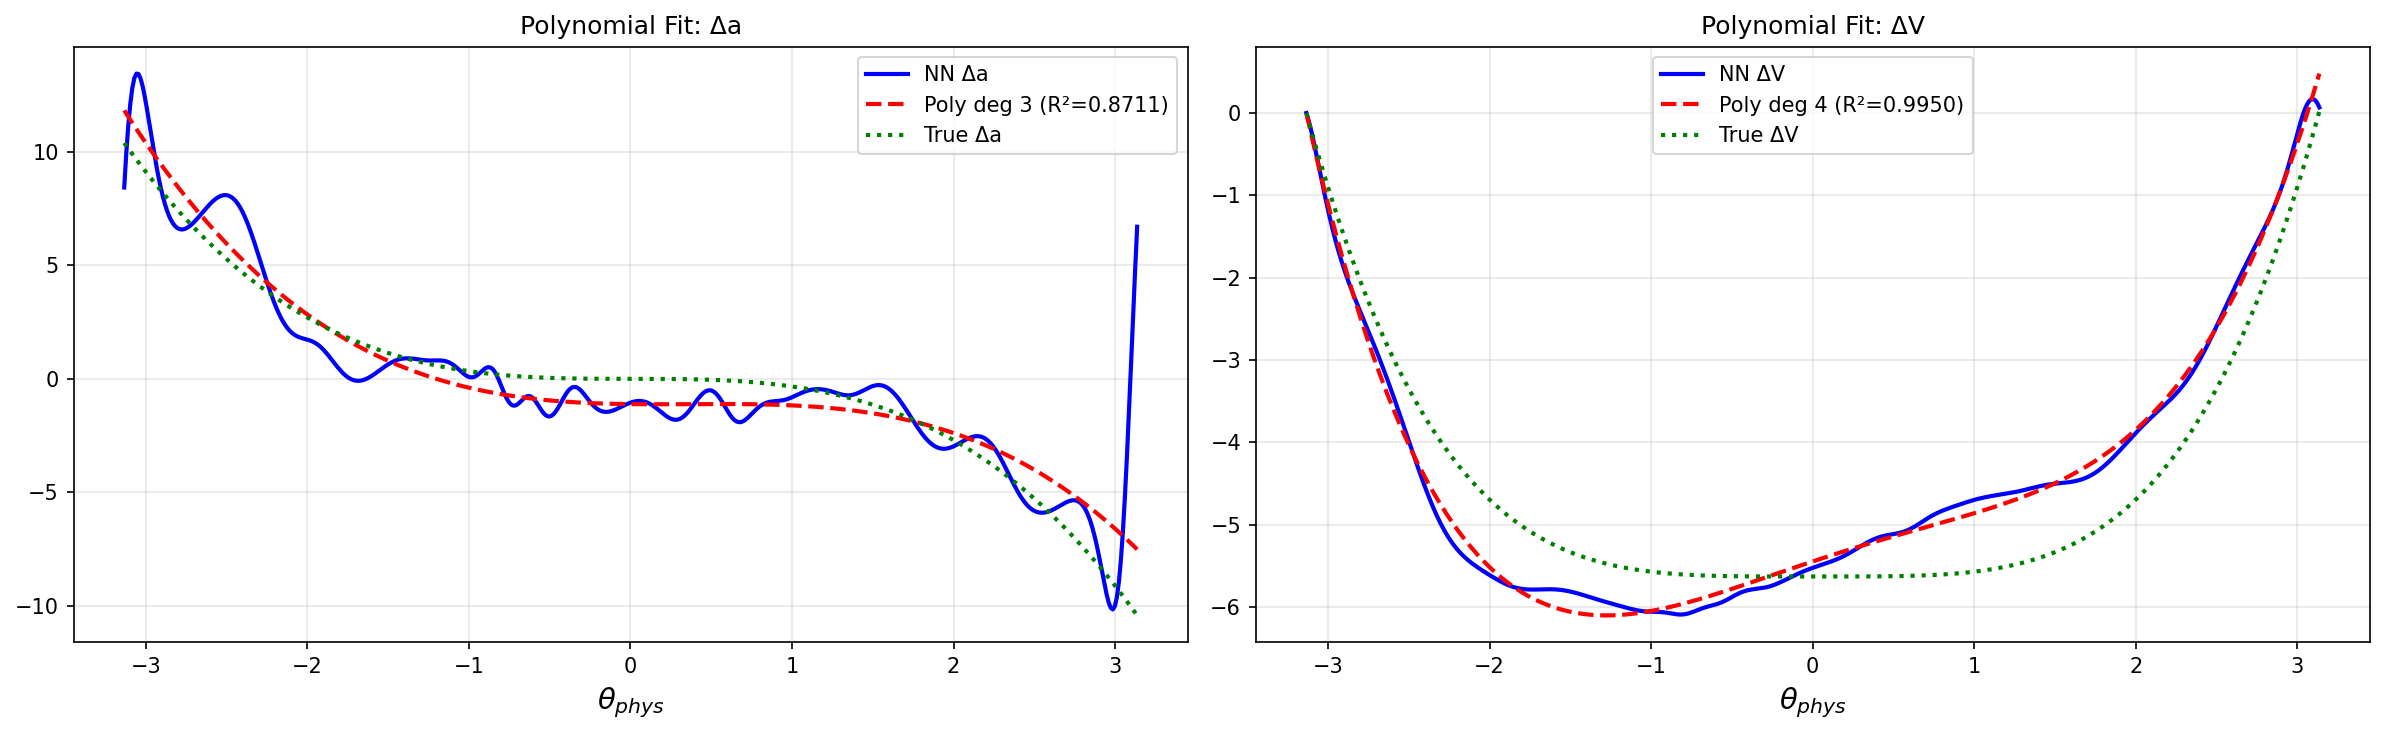

In [59]:
# Plot best polynomial fits
fig, axes = plt.subplots(1, 2, figsize=(16, 5), dpi=DPI)

coeffs_da = np.polyfit(theta_phys_sorted, delta_a_sorted, 3)
poly_da = np.polyval(coeffs_da, theta_phys_sorted)
r2_da = 1 - np.sum((delta_a_sorted - poly_da)**2) / np.sum((delta_a_sorted - delta_a_sorted.mean())**2)

ax = axes[0]
ax.plot(theta_phys_sorted, delta_a_sorted, 'b-', lw=2, label='NN Δa')
ax.plot(theta_phys_sorted, poly_da, 'r--', lw=2, label=f'Poly deg 3 (R²={r2_da:.4f})')
ax.plot(theta_phys_sorted, true_da, 'g:', lw=2, label='True Δa')
ax.set_xlabel(r'$\theta_{phys}$', fontsize=14)
ax.set_title('Polynomial Fit: Δa')
ax.legend()
ax.grid(True, alpha=0.3)

coeffs_dv = np.polyfit(theta_phys_sorted, delta_V_sorted, 4)
poly_dv = np.polyval(coeffs_dv, theta_phys_sorted)
r2_dv = 1 - np.sum((delta_V_sorted - poly_dv)**2) / np.sum((delta_V_sorted - delta_V_sorted.mean())**2)

ax = axes[1]
ax.plot(theta_phys_sorted, delta_V_sorted, 'b-', lw=2, label='NN ΔV')
ax.plot(theta_phys_sorted, poly_dv, 'r--', lw=2, label=f'Poly deg 4 (R²={r2_dv:.4f})')
ax.plot(theta_phys_sorted, true_dV, 'g:', lw=2, label='True ΔV')
ax.set_xlabel(r'$\theta_{phys}$', fontsize=14)
ax.set_title('Polynomial Fit: ΔV')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. SINDy

In [60]:
import pysindy as ps

print("=" * 65)
print("SINDy (POLYNOMIAL BASIS)")
print("=" * 65)

X_sindy = theta_phys_sorted.reshape(-1, 1)
thresholds = np.logspace(-3, 0, 20)

# --- Δa ---
print("\n--- Δa ---")
y_da = delta_a_sorted.reshape(-1, 1)

results_da = []
for thr in thresholds:
    opt = ps.STLSQ(threshold=thr, alpha=1e-5, max_iter=50)
    m = ps.SINDy(feature_library=ps.PolynomialLibrary(degree=5, include_bias=True), optimizer=opt)
    m.fit(X_sindy, t=1, x_dot=y_da, feature_names=['theta'])
    pred = np.array(m.predict(X_sindy))
    r2 = 1 - np.sum((y_da - pred)**2) / np.sum((y_da - y_da.mean())**2)
    coef = m.coefficients().flatten()
    n_act = np.sum(np.abs(coef) > 1e-10)
    results_da.append({'thr': thr, 'r2': r2, 'n': n_act, 'coef': coef, 'model': m, 'eq': m.equations(), 'names': m.get_feature_names()})

cands = [r for r in results_da if r['n'] <= 4 and r['r2'] > 0.5]
best_da = max(cands if cands else results_da, key=lambda r: r['r2'])

print(f"Best: R²={best_da['r2']:.6f}, {best_da['n']} terms, thr={best_da['thr']:.4f}")
print(f"  Eq: {best_da['eq'][0]}")
print(f"\n  {'Feature':<15s} {'SINDy':>10s} {'True':>10s} {'Ratio':>8s}")
print(f"  {'-'*45}")
true_da_map = {'1': 0, 'theta': -ALPHA1, 'theta^2': -ALPHA2, 'theta^3': -ALPHA3, 'theta^4': 0, 'theta^5': 0}
for name, c in zip(best_da['names'], best_da['coef']):
    if abs(c) > 1e-10:
        tv = true_da_map.get(name, 0)
        rat = f"{c/tv:.3f}" if abs(tv) > 1e-8 else ("SPUR" if abs(c) > 0.01 else "~0")
        print(f"  {name:<15s} {c:>10.4f} {tv:>10.4f} {rat:>8s}")

# --- ΔV ---
print("\n\n--- ΔV ---")
y_dv = delta_V_sorted.reshape(-1, 1)

results_dv = []
for thr in thresholds:
    opt = ps.STLSQ(threshold=thr, alpha=1e-5, max_iter=50)
    m = ps.SINDy(feature_library=ps.PolynomialLibrary(degree=6, include_bias=True), optimizer=opt)
    m.fit(X_sindy, t=1, x_dot=y_dv, feature_names=['theta'])
    pred = np.array(m.predict(X_sindy))
    r2 = 1 - np.sum((y_dv - pred)**2) / np.sum((y_dv - y_dv.mean())**2)
    coef = m.coefficients().flatten()
    n_act = np.sum(np.abs(coef) > 1e-10)
    results_dv.append({'thr': thr, 'r2': r2, 'n': n_act, 'coef': coef, 'model': m, 'eq': m.equations(), 'names': m.get_feature_names()})

cands = [r for r in results_dv if r['n'] <= 5 and r['r2'] > 0.5]
best_dv = max(cands if cands else results_dv, key=lambda r: r['r2'])

print(f"Best: R²={best_dv['r2']:.6f}, {best_dv['n']} terms, thr={best_dv['thr']:.4f}")
print(f"  Eq: {best_dv['eq'][0]}")
true_dv_theta4 = M_scale * ALPHA3 / 4
print(f"\n  {'Feature':<15s} {'SINDy':>10s} {'True':>10s} {'Ratio':>8s}")
print(f"  {'-'*45}")
true_dv_map = {'1': 0, 'theta': 0, 'theta^2': 0, 'theta^3': 0, 'theta^4': true_dv_theta4, 'theta^5': 0, 'theta^6': 0}
for name, c in zip(best_dv['names'], best_dv['coef']):
    if abs(c) > 1e-10:
        tv = true_dv_map.get(name, 0)
        rat = f"{c/tv:.3f}" if abs(tv) > 1e-8 else ("SPUR" if abs(c) > 0.01 else "~0")
        print(f"  {name:<15s} {c:>10.6f} {tv:>10.6f} {rat:>8s}")

/Users/harshit/miniconda3/envs/lagrangian_clean/lib/python3.9/site-packages/pysindy/optimizers/stlsq.py:224: UserWarning: Sparsity parameter is too big (0.3359818286283781) and eliminated all coefficients
  warnings.warn(
/Users/harshit/miniconda3/envs/lagrangian_clean/lib/python3.9/site-packages/pysindy/optimizers/stlsq.py:224: UserWarning: Sparsity parameter is too big (0.4832930238571752) and eliminated all coefficients
  warnings.warn(
/Users/harshit/miniconda3/envs/lagrangian_clean/lib/python3.9/site-packages/pysindy/optimizers/stlsq.py:224: UserWarning: Sparsity parameter is too big (0.6951927961775606) and eliminated all coefficients
  warnings.warn(
/Users/harshit/miniconda3/envs/lagrangian_clean/lib/python3.9/site-packages/pysindy/optimizers/stlsq.py:224: UserWarning: Sparsity parameter is too big (1.0) and eliminated all coefficients
  warnings.warn(


SINDy (POLYNOMIAL BASIS)

--- Δa ---
Best: R²=0.876213, 4 terms, thr=0.0379
  Eq: -0.784 1 + -0.082 theta + -0.305 theta^3 + 0.040 theta^4

  Feature              SINDy       True    Ratio
  ---------------------------------------------
  1                  -0.7837     0.0000     SPUR
  theta              -0.0821    -0.0000     SPUR
  theta^3            -0.3054    -0.3375    0.905
  theta^4             0.0395     0.0000     SPUR


--- ΔV ---
Best: R²=0.994998, 5 terms, thr=0.0014
  Eq: -5.445 1 + 0.652 theta + -0.074 theta^2 + -0.059 theta^3 + 0.066 theta^4

  Feature              SINDy       True    Ratio
  ---------------------------------------------
  1                -5.445022   0.000000     SPUR
  theta             0.652340   0.000000     SPUR
  theta^2          -0.074139   0.000000     SPUR
  theta^3          -0.058874   0.000000     SPUR
  theta^4           0.066358   0.058347    1.137


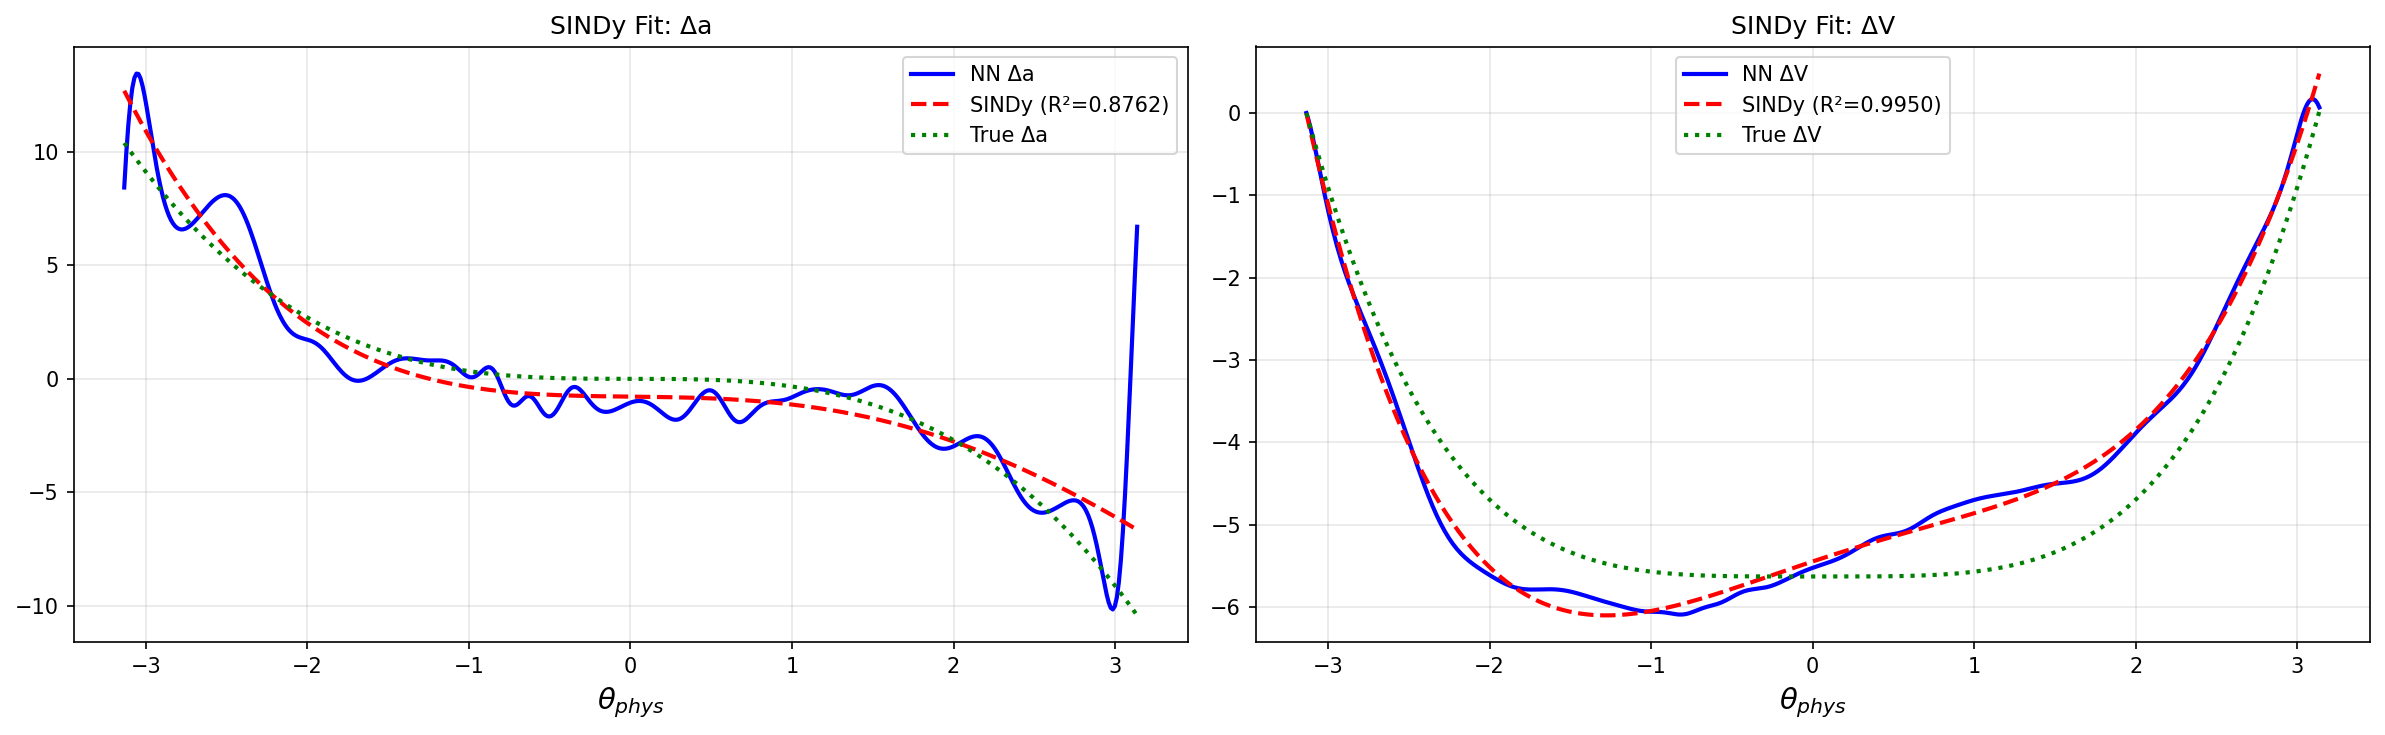

In [61]:
# SINDy fit plots
fig, axes = plt.subplots(1, 2, figsize=(16, 5), dpi=DPI)

pred_da_s = np.array(best_da['model'].predict(X_sindy)).flatten()
ax = axes[0]
ax.plot(theta_phys_sorted, delta_a_sorted, 'b-', lw=2, label='NN Δa')
ax.plot(theta_phys_sorted, pred_da_s, 'r--', lw=2, label=f'SINDy (R²={best_da["r2"]:.4f})')
ax.plot(theta_phys_sorted, true_da, 'g:', lw=2, label='True Δa')
ax.set_xlabel(r'$\theta_{phys}$', fontsize=14)
ax.set_title('SINDy Fit: Δa')
ax.legend(); ax.grid(True, alpha=0.3)

pred_dv_s = np.array(best_dv['model'].predict(X_sindy)).flatten()
ax = axes[1]
ax.plot(theta_phys_sorted, delta_V_sorted, 'b-', lw=2, label='NN ΔV')
ax.plot(theta_phys_sorted, pred_dv_s, 'r--', lw=2, label=f'SINDy (R²={best_dv["r2"]:.4f})')
ax.plot(theta_phys_sorted, true_dV, 'g:', lw=2, label='True ΔV')
ax.set_xlabel(r'$\theta_{phys}$', fontsize=14)
ax.set_title('SINDy Fit: ΔV')
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. PySR (Symbolic Regression)

Genetic-programming symbolic regression on Δa and ΔV.

PySR: Perturbation Acceleration (Δa)

Expressions evaluated per second: 8.660e+05
Progress: 1792 / 9000 total iterations (19.911%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           1.692e+01  0.000e+00  y = -0.025236
3           5.183e+00  5.917e-01  y = theta * -1.8884
5           5.183e+00  1.904e-05  y = (-0.0074905 - theta) * 1.8884
7           3.150e+00  2.490e-01  y = (theta * (theta * -0.31678)) * theta
9           2.735e+00  7.054e-02  y = (0.45998 - theta) * ((theta * 0.31702) * theta)
11          2.185e+00  1.123e-01  y = ((theta * -0.31707) * ((theta + -1.0534) * theta)) - 1...
                                      .1137
13          2.099e+00  2.020e-02  y = ((((theta * theta) * (theta + -8.0267)) * theta) * 0.0...
                                      39507) - 0.78378
19 

/Users/harshit/miniconda3/envs/lagrangian_clean/lib/python3.9/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/Users/harshit/miniconda3/envs/lagrangian_clean/lib/python3.9/site-packages/pysr/sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic searches.
  warnings.warn(
[ Info: Started!
[ Info: Final population:
[ Info: Results saved to:


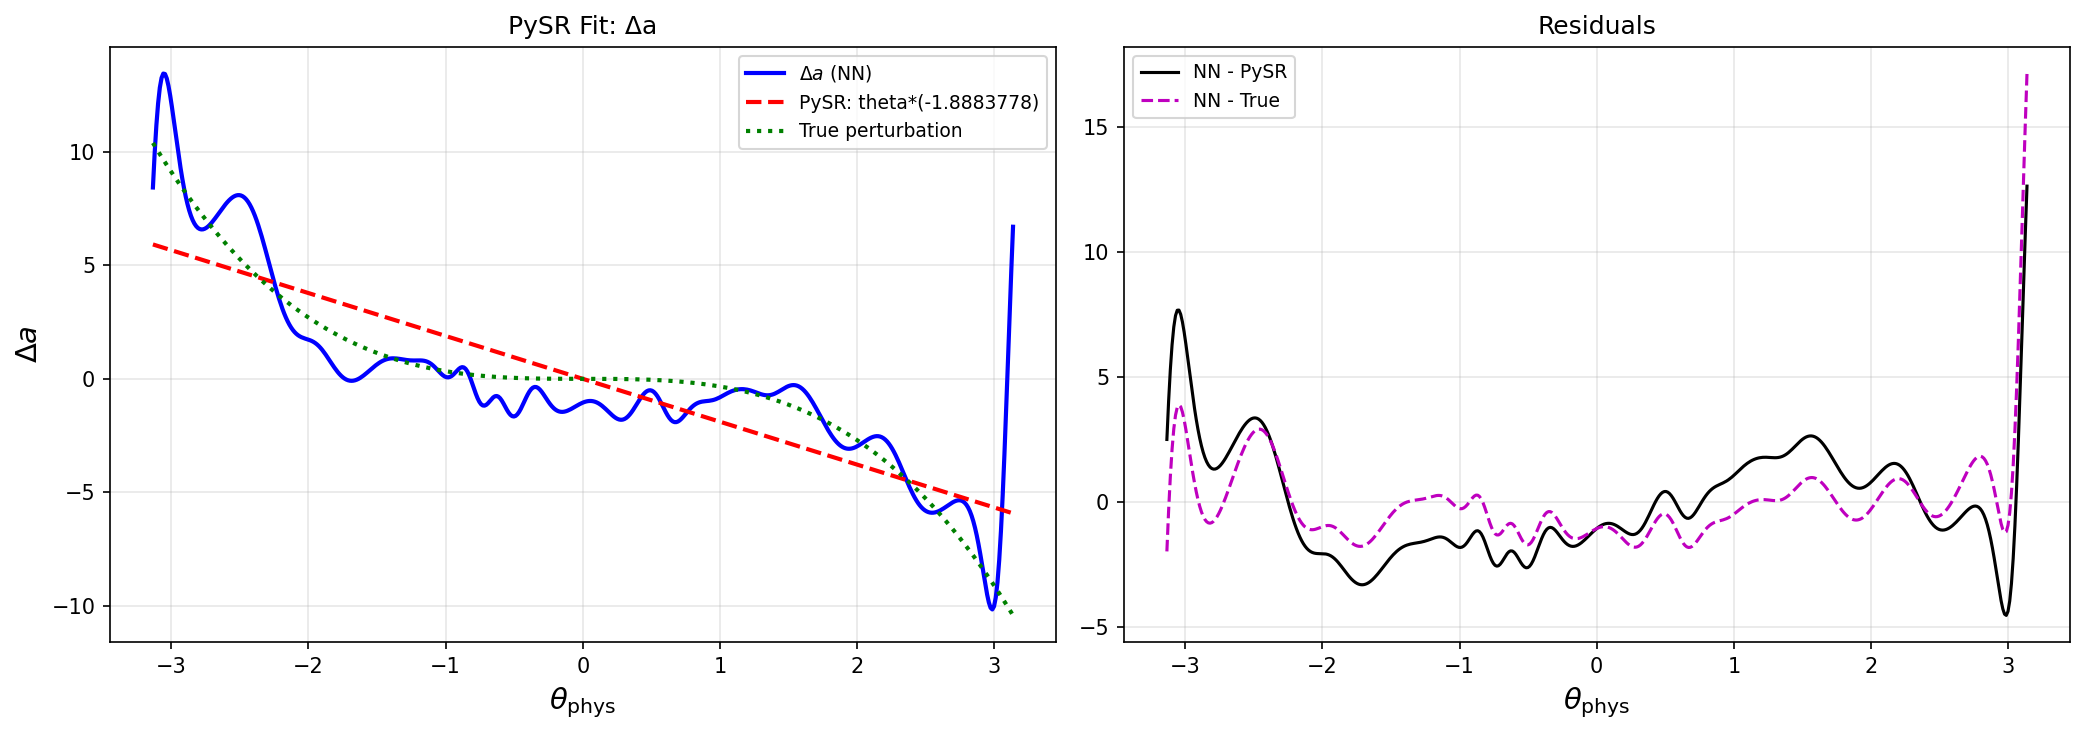


PySR equation table:
   complexity       loss                                                                                                 equation
0           1  16.924994                                                                                             -0.025235968
1           3   5.182730                                                                                       theta * -1.8883778
2           5   5.182530                                                                      (-0.0074904715 - theta) * 1.8883624
3           7   3.149859                                                                  (theta * (theta * -0.31678084)) * theta
4           9   2.735403                                                    (0.45998254 - theta) * ((theta * 0.31702426) * theta)
5          11   2.185160                                     ((theta * -0.31706652) * ((theta + -1.0533944) * theta)) - 1.1136998
6          13   2.098640                            ((((theta * thet

In [62]:
from pysr import PySRRegressor

print("=" * 65)
print("PySR: Perturbation Acceleration (Δa)")
print("=" * 65)

X_fit = theta_phys_sorted.reshape(-1, 1)

sr_da = PySRRegressor(
    niterations=300,
    binary_operators=['+', '-', '*'],
    unary_operators=[],
    denoise=False,
    model_selection='best',
    maxsize=20,
    parsimony=0.005,
    populations=30,
    population_size=50,
    ncycles_per_iteration=550,
    weight_optimize=0.001,
    adaptive_parsimony_scaling=1000,
    random_state=42,
    procs=4,
    temp_equation_file=True,
)
sr_da.fit(X_fit, delta_a_sorted, variable_names=['theta'])

# Select best by max score
eqs_da = sr_da.equations_
scores_da = eqs_da['score'].values.astype(float)
best_idx_da = eqs_da.index[np.argmax(scores_da)]
expr_da = sr_da.sympy(index=best_idx_da)
pred_da_pysr = sr_da.predict(X_fit, index=best_idx_da)

print(f"\nBest expression: {expr_da}")
print(f"Complexity: {eqs_da.loc[best_idx_da, 'complexity']}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=DPI)

axes[0].plot(theta_phys_sorted, delta_a_sorted, 'b-', lw=2, label=r'$\Delta a$ (NN)')
axes[0].plot(theta_phys_sorted, pred_da_pysr, 'r--', lw=2, label=f'PySR: {expr_da}')
axes[0].plot(theta_phys_sorted, true_da, 'g:', lw=2, label='True perturbation')
axes[0].set_xlabel(r'$\theta_{\mathrm{phys}}$', fontsize=14)
axes[0].set_ylabel(r'$\Delta a$', fontsize=14)
axes[0].set_title('PySR Fit: Δa')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].plot(theta_phys_sorted, delta_a_sorted - pred_da_pysr, 'k-', lw=1.5, label='NN - PySR')
axes[1].plot(theta_phys_sorted, delta_a_sorted - true_da, 'm--', lw=1.5, label='NN - True')
axes[1].set_xlabel(r'$\theta_{\mathrm{phys}}$', fontsize=14)
axes[1].set_title('Residuals')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nPySR equation table:")
print(sr_da.equations_[['complexity', 'loss', 'equation']].to_string())

/Users/harshit/miniconda3/envs/lagrangian_clean/lib/python3.9/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/Users/harshit/miniconda3/envs/lagrangian_clean/lib/python3.9/site-packages/pysr/sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic searches.
  warnings.warn(
[ Info: Started!


PySR: Perturbation Potential (ΔV)

Expressions evaluated per second: 1.000e+06
Progress: 2153 / 9000 total iterations (23.922%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           2.688e+00  0.000e+00  y = -4.3941
3           2.688e+00  -0.000e+00  y = 1.3269 * -3.3114
5           2.380e+00  6.098e-02  y = (theta * 0.30616) + -4.3959
7           6.347e-01  6.608e-01  y = (theta * (theta * 0.48736)) + -5.999
9           3.309e-01  3.256e-01  y = (theta * ((theta + 0.62395) * 0.48679)) + -5.9989
11          3.309e-01  5.960e-08  y = (theta * (((theta + 0.72339) * 0.48681) - 0.048421)) +...
                                       -5.9991
13          9.325e-02  6.333e-01  y = (((theta * (theta * (theta * 0.058271))) + 0.30384) * ...
                                      theta) + -5.5316
15 

[ Info: Final population:
[ Info: Results saved to:


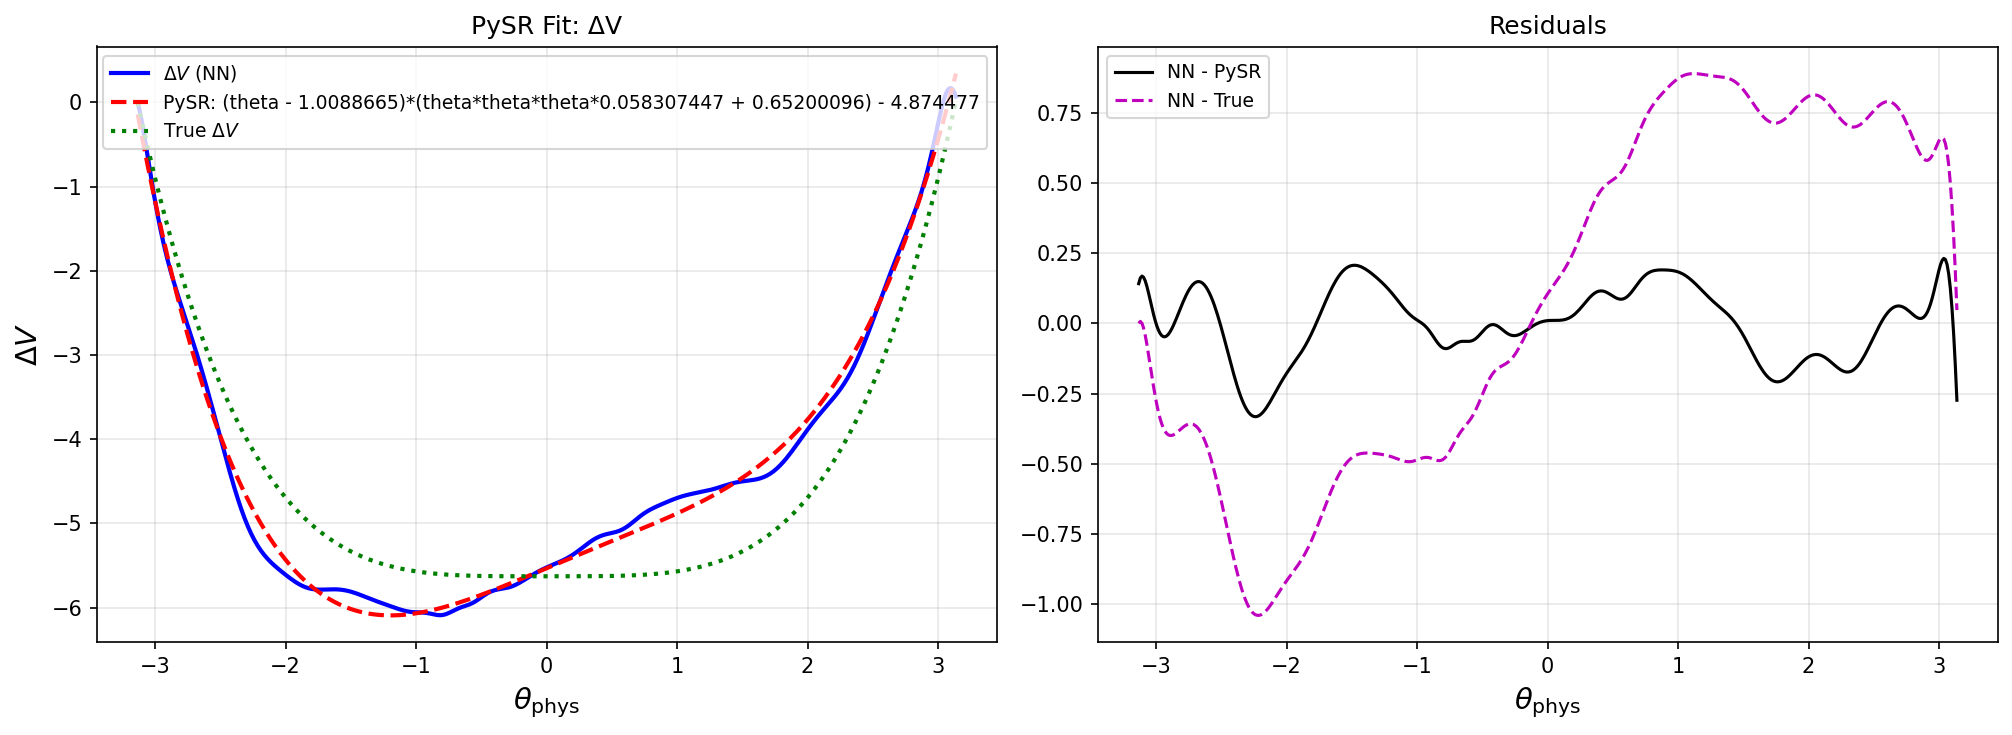


PySR equation table:
   complexity      loss                                                                                                                equation
0           1  2.688423                                                                                                              -4.3941264
1           3  2.688423                                                                                                  1.3269228 * -3.3114328
2           5  2.379738                                                                                        (theta * 0.30616355) + -4.395922
3           7  0.634719                                                                               (theta * (theta * 0.4873643)) + -5.999035
4           9  0.330931                                                               (theta * ((theta + 0.6239521) * 0.48679203)) + -5.9989185
5          11  0.258353                                                     ((theta * (theta * -0.04942326)) + 0.6

In [63]:
from pysr import PySRRegressor

print("=" * 65)
print("PySR: Perturbation Potential (ΔV)")
print("=" * 65)

sr_dv = PySRRegressor(
    niterations=300,
    binary_operators=['+', '-', '*'],
    unary_operators=[],
    denoise=False,
    model_selection='best',
    maxsize=20,
    parsimony=0.005,
    populations=30,
    population_size=50,
    ncycles_per_iteration=550,
    weight_optimize=0.001,
    adaptive_parsimony_scaling=1000,
    random_state=42,
    procs=4,
    temp_equation_file=True,
)
sr_dv.fit(X_fit, delta_V_sorted, variable_names=['theta'])

# Select best by max score
eqs_dv = sr_dv.equations_
scores_dv = eqs_dv['score'].values.astype(float)
best_idx_dv = eqs_dv.index[np.argmax(scores_dv)]
expr_dv = sr_dv.sympy(index=best_idx_dv)
pred_dv_pysr = sr_dv.predict(X_fit, index=best_idx_dv)

print(f"\nBest expression: {expr_dv}")
print(f"Complexity: {eqs_dv.loc[best_idx_dv, 'complexity']}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=DPI)

axes[0].plot(theta_phys_sorted, delta_V_sorted, 'b-', lw=2, label=r'$\Delta V$ (NN)')
axes[0].plot(theta_phys_sorted, pred_dv_pysr, 'r--', lw=2, label=f'PySR: {expr_dv}')
axes[0].plot(theta_phys_sorted, true_dV, 'g:', lw=2, label=r'True $\Delta V$')
axes[0].set_xlabel(r'$\theta_{\mathrm{phys}}$', fontsize=14)
axes[0].set_ylabel(r'$\Delta V$', fontsize=14)
axes[0].set_title('PySR Fit: ΔV')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].plot(theta_phys_sorted, delta_V_sorted - pred_dv_pysr, 'k-', lw=1.5, label='NN - PySR')
axes[1].plot(theta_phys_sorted, delta_V_sorted - true_dV, 'm--', lw=1.5, label='NN - True')
axes[1].set_xlabel(r'$\theta_{\mathrm{phys}}$', fontsize=14)
axes[1].set_title('Residuals')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nPySR equation table:")
print(sr_dv.equations_[['complexity', 'loss', 'equation']].to_string())

## 7b. Expand PySR Expressions to Standard Polynomial Form

Expand PySR's nested/factored expressions to polynomial coefficients for direct comparison with ground truth.

In [64]:
import sympy as sp

theta_sym = sp.Symbol('theta')

def expand_to_poly_coeffs(expr_sympy, symbol, max_degree=6):
    """Expand a sympy expression into polynomial coefficients."""
    poly = sp.Poly(sp.expand(expr_sympy), symbol)
    coeffs = {}
    for monom, coeff in poly.as_dict().items():
        deg = monom[0]
        coeffs[deg] = float(coeff)
    return coeffs

def print_poly_comparison(label, expr_sympy, true_coeffs, symbol):
    """Print expanded polynomial vs ground truth."""
    expanded = sp.expand(expr_sympy)
    print(f"\n{'='*60}")
    print(f"  {label}")
    print(f"{'='*60}")
    print(f"  PySR (raw):      {expr_sympy}")
    print(f"  PySR (expanded): {expanded}")
    
    try:
        fitted_coeffs = expand_to_poly_coeffs(expr_sympy, symbol)
    except Exception as e:
        print(f"  (Cannot expand to polynomial: {e})")
        return
    
    max_deg = max(
        max(fitted_coeffs.keys()) if fitted_coeffs else 0,
        max(true_coeffs.keys()) if true_coeffs else 0
    )
    
    print(f"\n  {'Degree':<8} {'Fitted':>12} {'True':>12} {'Ratio':>10}")
    print(f"  {'-'*44}")
    for d in range(max_deg + 1):
        f = fitted_coeffs.get(d, 0.0)
        t = true_coeffs.get(d, 0.0)
        ratio = f"{f/t:.3f}" if abs(t) > 1e-6 else ("SPUR" if abs(f) > 0.01 else "---")
        print(f"  {d:<8} {f:>12.4f} {t:>12.4f} {ratio:>10}")

# Ground truth for Δa: -α₃θ³ (pure cubic)
true_da_coeffs = {0: 0.0, 1: -ALPHA1, 2: -ALPHA2, 3: -ALPHA3}

# Ground truth for ΔV: M_scale * (α₃/4)θ⁴
true_dV_coeffs = {
    0: 0.0, 1: 0.0,
    2: M_scale * ALPHA1/2,
    3: M_scale * ALPHA2/3,
    4: M_scale * ALPHA3/4,
}

# ---- Δa: all PySR candidates ----
print("ACCELERATION SPACE: Δa(θ)")
print("=" * 60)

eqs_a = sr_da.equations_
for row_idx in range(len(eqs_a)):
    cx = int(eqs_a.iloc[row_idx]['complexity'])
    loss = float(eqs_a.iloc[row_idx]['loss'])
    expr = sr_da.sympy(index=eqs_a.index[row_idx])
    try:
        coeffs = expand_to_poly_coeffs(expr, theta_sym)
        max_deg = max(coeffs.keys()) if coeffs else 0
        coeff_str = " + ".join(
            f"{coeffs.get(d, 0):+.4f}\u00b7\u03b8^{d}" for d in range(max_deg + 1)
        )
        print(f"  cx={cx:2d}  loss={loss:.4f}  {coeff_str}")
    except:
        print(f"  cx={cx:2d}  loss={loss:.4f}  (non-polynomial: {expr})")

print(f"\n  TRUE: -0.3375\u00b7\u03b8^3  (pure cubic)")

# Detailed comparison for best cubic-like expressions
print("\n\nBest candidate expressions (detailed):")
for row_idx in range(len(eqs_a)):
    cx = int(eqs_a.iloc[row_idx]['complexity'])
    if cx in [7, 9, 11, 13, 15]:
        expr = sr_da.sympy(index=eqs_a.index[row_idx])
        print_poly_comparison(
            f"\u0394a \u2014 complexity {cx} (loss={float(eqs_a.iloc[row_idx]['loss']):.4f})",
            expr, true_da_coeffs, theta_sym
        )

# ---- ΔV: all PySR candidates ----
print("\n\n" + "=" * 60)
print("POTENTIAL SPACE: ΔV(θ)")
print("=" * 60)

eqs_V = sr_dv.equations_
for row_idx in range(len(eqs_V)):
    cx = int(eqs_V.iloc[row_idx]['complexity'])
    loss = float(eqs_V.iloc[row_idx]['loss'])
    expr = sr_dv.sympy(index=eqs_V.index[row_idx])
    try:
        coeffs = expand_to_poly_coeffs(expr, theta_sym)
        max_deg = max(coeffs.keys()) if coeffs else 0
        coeff_str = " + ".join(
            f"{coeffs.get(d, 0):+.4f}\u00b7\u03b8^{d}" for d in range(max_deg + 1)
        )
        print(f"  cx={cx:2d}  loss={loss:.4f}  {coeff_str}")
    except:
        print(f"  cx={cx:2d}  loss={loss:.4f}  (non-polynomial: {expr})")

true_dv_t4 = M_scale * ALPHA3 / 4
print(f"\n  TRUE (\u00d7M={M_scale:.4f}): {true_dv_t4:+.4f}\u00b7\u03b8^4  (pure quartic)")

# Detailed comparison for best quartic-like expressions
print("\n\nBest candidate expressions (detailed):")
for row_idx in range(len(eqs_V)):
    cx = int(eqs_V.iloc[row_idx]['complexity'])
    if cx in [9, 13, 15, 17]:
        expr = sr_dv.sympy(index=eqs_V.index[row_idx])
        print_poly_comparison(
            f"\u0394V \u2014 complexity {cx} (loss={float(eqs_V.iloc[row_idx]['loss']):.4f})",
            expr, true_dV_coeffs, theta_sym
        )

ACCELERATION SPACE: Δa(θ)
  cx= 1  loss=16.9250  -0.0252·θ^0
  cx= 3  loss=5.1827  +0.0000·θ^0 + -1.8884·θ^1
  cx= 5  loss=5.1825  -0.0141·θ^0 + -1.8884·θ^1
  cx= 7  loss=3.1499  +0.0000·θ^0 + +0.0000·θ^1 + +0.0000·θ^2 + -0.3168·θ^3
  cx= 9  loss=2.7354  +0.0000·θ^0 + +0.0000·θ^1 + +0.1458·θ^2 + -0.3170·θ^3
  cx=11  loss=2.1852  -1.1137·θ^0 + +0.0000·θ^1 + +0.3340·θ^2 + -0.3171·θ^3
  cx=13  loss=2.0986  -0.7838·θ^0 + +0.0000·θ^1 + +0.0000·θ^2 + -0.3171·θ^3 + +0.0395·θ^4
  cx=17  loss=2.0951  -0.7836·θ^0 + -0.0821·θ^1 + +0.0000·θ^2 + -0.3055·θ^3 + +0.0395·θ^4

  TRUE: -0.3375·θ^3  (pure cubic)


Best candidate expressions (detailed):

  Δa — complexity 7 (loss=3.1499)
  PySR (raw):      theta*theta*(-0.31678084)*theta
  PySR (expanded): -0.31678084*theta**3

  Degree         Fitted         True      Ratio
  --------------------------------------------
  0              0.0000       0.0000        ---
  1              0.0000      -0.0000        ---
  2              0.0000      -0.0000     

## 9. Summary

In [66]:
from sklearn.metrics import r2_score
import sympy as sp

print("=" * 80)
print("     TEST 1: PURE CUBIC PERTURBATION — SUMMARY REPORT")
print("=" * 80)

# ---- Ground truth ----
true_dv_t4 = M_scale * ALPHA3 / 4
true_dv_t3 = M_scale * ALPHA2 / 3
true_dv_t2 = M_scale * ALPHA1 / 2

print(f"\nTrue perturbation:")
print(f"  Δa = {-ALPHA1:.4f}·θ + {-ALPHA2:.4f}·θ² + {-ALPHA3:.4f}·θ³")
print(f"  ΔV = {true_dv_t2:.6f}·θ² + {true_dv_t3:.6f}·θ³ + {true_dv_t4:.6f}·θ⁴  (×M_scale={M_scale:.4f})")

# ---- R² ----
print(f"\nR² (signal quality):")
print(f"  Δa vs true Δa: {r2_score(true_da, delta_a_sorted):.4f}")
print(f"  ΔV vs true ΔV: {r2_score(true_dV, delta_V_sorted):.4f}")

# ============================================================
# 1. Polynomial Regression
# ============================================================
print(f"\n{'='*80}")
print("  1. POLYNOMIAL REGRESSION")
print(f"{'='*80}")

c_da = np.polyfit(theta_phys_sorted, delta_a_sorted, 3)
c_dv = np.polyfit(theta_phys_sorted, delta_V_sorted, 4)

poly_da_pred = np.polyval(c_da, theta_phys_sorted)
poly_dv_pred = np.polyval(c_dv, theta_phys_sorted)
r2_poly_da = 1 - np.sum((delta_a_sorted - poly_da_pred)**2) / np.sum((delta_a_sorted - delta_a_sorted.mean())**2)
r2_poly_dv = 1 - np.sum((delta_V_sorted - poly_dv_pred)**2) / np.sum((delta_V_sorted - delta_V_sorted.mean())**2)

print(f"\n  Δa (degree 3, R²={r2_poly_da:.4f}):")
print(f"    {'Term':<8} {'Fitted':>12} {'True':>12} {'Ratio':>10} {'Status':>10}")
print(f"    {'-'*54}")
for i, (power, true_val) in enumerate([(3, -ALPHA3), (2, -ALPHA2), (1, -ALPHA1), (0, 0)]):
    ratio = f"{c_da[i]/true_val:.3f}" if abs(true_val) > 1e-8 else ("SPURIOUS" if abs(c_da[i]) > 0.01 else "~0")
    status = "OK" if (abs(true_val) > 1e-8 and 0.8 < abs(c_da[i]/true_val) < 1.2) else ("SPURIOUS" if abs(true_val) < 1e-8 and abs(c_da[i]) > 0.01 else "~0" if abs(c_da[i]) < 0.01 else "OFF")
    print(f"    θ^{power:<5} {c_da[i]:>12.4f} {true_val:>12.4f} {ratio:>10} {status:>10}")

print(f"\n  ΔV (degree 4, R²={r2_poly_dv:.4f}):")
print(f"    {'Term':<8} {'Fitted':>12} {'True':>12} {'Ratio':>10} {'Status':>10}")
print(f"    {'-'*54}")
true_dv_list = [true_dv_t4, true_dv_t3, true_dv_t2, 0, 0]
for i, power in enumerate([4, 3, 2, 1, 0]):
    true_val = true_dv_list[i]
    ratio = f"{c_dv[i]/true_val:.3f}" if abs(true_val) > 1e-8 else ("SPURIOUS" if abs(c_dv[i]) > 0.001 else "~0")
    status = "OK" if (abs(true_val) > 1e-8 and 0.8 < abs(c_dv[i]/true_val) < 1.2) else ("SPURIOUS" if abs(true_val) < 1e-8 and abs(c_dv[i]) > 0.001 else "~0" if abs(c_dv[i]) < 0.001 else "OFF")
    print(f"    θ^{power:<5} {c_dv[i]:>12.6f} {true_val:>12.6f} {ratio:>10} {status:>10}")

# ============================================================
# 2. SINDy
# ============================================================
print(f"\n{'='*80}")
print("  2. SINDy (Sparse Identification of Nonlinear Dynamics)")
print(f"{'='*80}")

print(f"\n  Δa: {best_da['eq'][0]}")
print(f"       R²={best_da['r2']:.4f}, {best_da['n']} active terms, threshold={best_da['thr']:.4f}")
print(f"    {'Feature':<15} {'SINDy':>12} {'True':>12} {'Ratio':>10}")
print(f"    {'-'*51}")
true_da_map = {'1': 0, 'theta': -ALPHA1, 'theta^2': -ALPHA2, 'theta^3': -ALPHA3, 'theta^4': 0, 'theta^5': 0}
for fname, coeff in zip(best_da['names'], best_da['coef']):
    if abs(coeff) > 1e-10:
        tv = true_da_map.get(fname, 0)
        ratio = f"{coeff/tv:.3f}" if abs(tv) > 1e-8 else ("SPURIOUS" if abs(coeff) > 0.01 else "~0")
        print(f"    {fname:<15} {coeff:>12.4f} {tv:>12.4f} {ratio:>10}")

print(f"\n  ΔV: {best_dv['eq'][0]}")
print(f"       R²={best_dv['r2']:.4f}, {best_dv['n']} active terms, threshold={best_dv['thr']:.4f}")
print(f"    {'Feature':<15} {'SINDy':>12} {'True':>12} {'Ratio':>10}")
print(f"    {'-'*51}")
true_dv_map = {'1': 0, 'theta': 0, 'theta^2': true_dv_t2, 'theta^3': true_dv_t3, 'theta^4': true_dv_t4, 'theta^5': 0, 'theta^6': 0}
for fname, coeff in zip(best_dv['names'], best_dv['coef']):
    if abs(coeff) > 1e-10:
        tv = true_dv_map.get(fname, 0)
        ratio = f"{coeff/tv:.3f}" if abs(tv) > 1e-8 else ("SPURIOUS" if abs(coeff) > 0.001 else "~0")
        print(f"    {fname:<15} {coeff:>12.6f} {tv:>12.6f} {ratio:>10}")

# ============================================================
# 3. PySR
# ============================================================
print(f"\n{'='*80}")
print("  3. PySR (Symbolic Regression)")
print(f"{'='*80}")

theta_sym = sp.Symbol('theta')

def expand_to_poly(expr, symbol, max_deg=6):
    try:
        poly = sp.Poly(sp.expand(expr), symbol)
        return {m[0]: float(c) for m, c in poly.as_dict().items()}
    except:
        return None

print(f"\n  Δa: {expr_da}")
da_coeffs = expand_to_poly(expr_da, theta_sym)
if da_coeffs:
    print(f"    {'Degree':<8} {'PySR':>12} {'True':>12} {'Ratio':>10}")
    print(f"    {'-'*44}")
    max_d = max(max(da_coeffs.keys()), 3)
    true_da_by_deg = {1: -ALPHA1, 2: -ALPHA2, 3: -ALPHA3}
    for d in range(max_d + 1):
        pv = da_coeffs.get(d, 0)
        tv = true_da_by_deg.get(d, 0)
        if abs(pv) > 1e-6 or abs(tv) > 1e-6:
            ratio = f"{pv/tv:.3f}" if abs(tv) > 1e-8 else ("SPURIOUS" if abs(pv) > 0.01 else "~0")
            print(f"    θ^{d:<5} {pv:>12.4f} {tv:>12.4f} {ratio:>10}")

print(f"\n  ΔV: {expr_dv}")
dv_coeffs = expand_to_poly(expr_dv, theta_sym)
if dv_coeffs:
    print(f"    {'Degree':<8} {'PySR':>12} {'True':>12} {'Ratio':>10}")
    print(f"    {'-'*44}")
    max_d = max(max(dv_coeffs.keys()), 4)
    true_dv_by_deg = {2: true_dv_t2, 3: true_dv_t3, 4: true_dv_t4}
    for d in range(max_d + 1):
        pv = dv_coeffs.get(d, 0)
        tv = true_dv_by_deg.get(d, 0)
        if abs(pv) > 1e-6 or abs(tv) > 1e-6:
            ratio = f"{pv/tv:.3f}" if abs(tv) > 1e-8 else ("SPURIOUS" if abs(pv) > 0.001 else "~0")
            print(f"    θ^{d:<5} {pv:>12.6f} {tv:>12.6f} {ratio:>10}")

# ============================================================
# Comparison table
# ============================================================
print(f"\n{'='*80}")
print("  DOMINANT TERM RECOVERY COMPARISON")
print(f"{'='*80}")

# Δa θ³ coefficient from each method
poly_da3 = c_da[0]
sindy_da3 = 0
for fname, coeff in zip(best_da['names'], best_da['coef']):
    if fname == 'theta^3':
        sindy_da3 = coeff
pysr_da3 = expand_to_poly(expr_da, theta_sym).get(3, 0) if expand_to_poly(expr_da, theta_sym) else 0

# ΔV θ⁴ coefficient from each method
poly_dv4 = c_dv[0]
sindy_dv4 = 0
for fname, coeff in zip(best_dv['names'], best_dv['coef']):
    if fname == 'theta^4':
        sindy_dv4 = coeff
pysr_dv4 = expand_to_poly(expr_dv, theta_sym).get(4, 0) if expand_to_poly(expr_dv, theta_sym) else 0

print(f"\n  {'Method':<20} {'Δa θ³':>12} {'ratio':>8} {'ΔV θ⁴':>12} {'ratio':>8}")
print(f"  {'-'*62}")
print(f"  {'True':<20} {-ALPHA3:>12.4f} {'':>8} {true_dv_t4:>12.6f} {'':>8}")
print(f"  {'Poly Regression':<20} {poly_da3:>12.4f} {poly_da3/(-ALPHA3):>8.3f} {poly_dv4:>12.6f} {poly_dv4/true_dv_t4:>8.3f}")
print(f"  {'SINDy':<20} {sindy_da3:>12.4f} {sindy_da3/(-ALPHA3):>8.3f} {sindy_dv4:>12.6f} {sindy_dv4/true_dv_t4:>8.3f}")
print(f"  {'PySR':<20} {pysr_da3:>12.4f} {pysr_da3/(-ALPHA3):>8.3f} {pysr_dv4:>12.6f} {pysr_dv4/true_dv_t4:>8.3f}")

print(f"\n{'='*80}")


     TEST 1: PURE CUBIC PERTURBATION — SUMMARY REPORT

True perturbation:
  Δa = -0.0000·θ + -0.0000·θ² + -0.3375·θ³
  ΔV = 0.000000·θ² + 0.000000·θ³ + 0.058347·θ⁴  (×M_scale=0.6915)

R² (signal quality):
  Δa vs true Δa: 0.7948
  ΔV vs true ΔV: 0.8227

  1. POLYNOMIAL REGRESSION

  Δa (degree 3, R²=0.8711):
    Term           Fitted         True      Ratio     Status
    ------------------------------------------------------
    θ^3          -0.3051      -0.3375      0.904         OK
    θ^2           0.3340      -0.0000   SPURIOUS   SPURIOUS
    θ^1          -0.0840      -0.0000   SPURIOUS   SPURIOUS
    θ^0          -1.1136       0.0000   SPURIOUS   SPURIOUS

  ΔV (degree 4, R²=0.9950):
    Term           Fitted         True      Ratio     Status
    ------------------------------------------------------
    θ^4         0.066358     0.058347      1.137         OK
    θ^3        -0.058874     0.000000   SPURIOUS   SPURIOUS
    θ^2        -0.074139     0.000000   SPURIOUS   SPURIOUS
 